## All Packages needed

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import os

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import scipy.ndimage
from scipy import misc
from glob import glob
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
import skimage
import imageio
import seaborn as sns
from PIL import Image
import glob
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

/tmp/ipykernel_3795854/91456258.py:14: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


device(type='cuda')

# Data loading & inspection
## Getting shape of CSV file
## And summary of data types

In [2]:
#Getting a summary of the number of images and the different class IDs

df = pd.read_csv('labels_train.csv')
df.shape
df


,file_name,class_id
0,img_4358977458434011046.jpg,1
1,img_5224016757187192130.jpg,2
2,img_3065202206106254707.jpg,2
3,img_6304894865561547174.jpg,1
4,img_3371338542810939877.jpg,2
...,...,...
4667,img_6661311872293090412.jpg,2
4668,img_3844568579349757418.jpg,1
4669,img_9145812369383814369.jpg,1
4670,img_1311393330250392648.jpg,1


In [4]:
# Need to create folders for each X-ray type to store the images
types = df['class_id'].unique()
print(types)

[1 2 0]


# Feature-level analysis

## There are 3 image classes:

Class 0: no disease

Class 1: bacterial pneumonia

Class 2: viral pneumonia

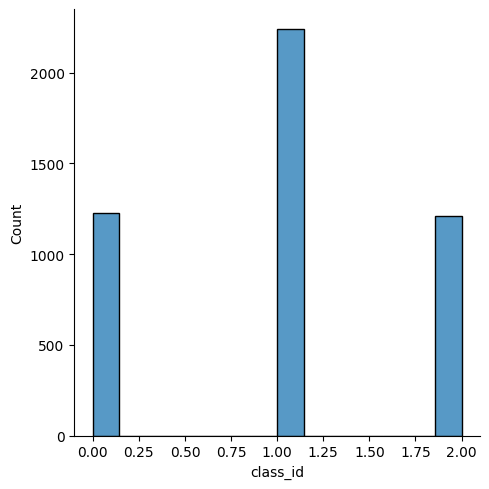

In [5]:
#visualization displot of the different classes and their image counts

sns.displot(df['class_id'])
plt.show()

## Discuss any class imbalance, possible bias, noise

There are many more bacterial image X-rays of pneumonia than there are normal and viral X-rays. We can fix this class imbalance with class weights.

## Missing values, outliers, duplicates

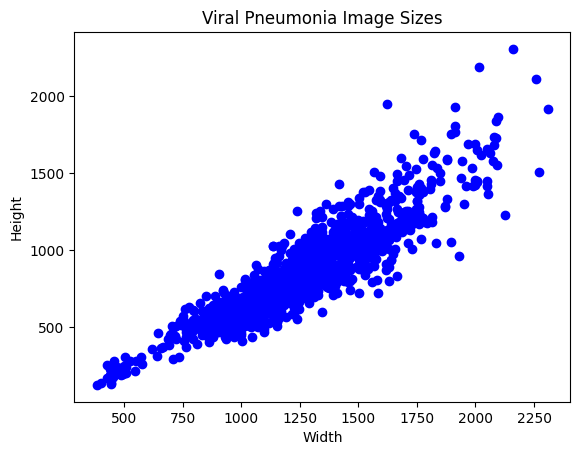

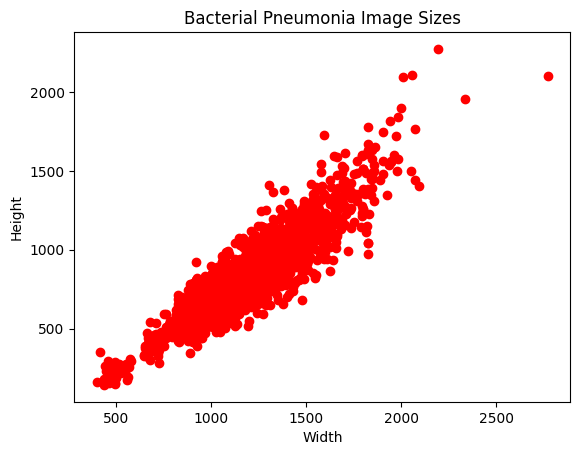

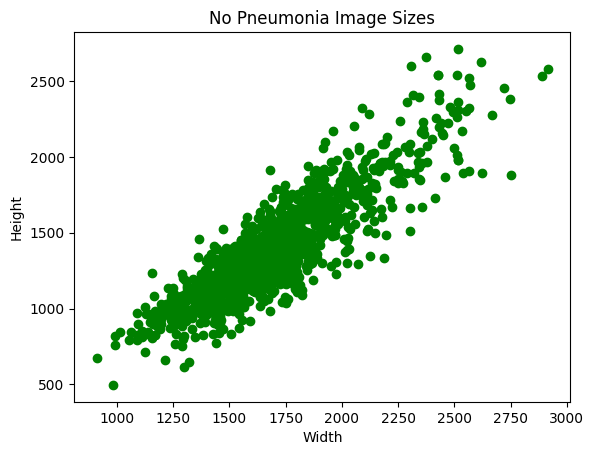

In [6]:
from PIL import Image
import os
import matplotlib.pyplot as plt

# Class folders inside final_train
base_dir = 'final_train'
classes = ['viral_pneumonia', 'bacterial_pneumonia', 'no_pneumonia']

vp_w, vp_h = [], []
bp_w, bp_h = [], []
np_w, np_h = [], []

for label in classes:
    folder_path = os.path.join(base_dir, label)
    
    for filename in os.listdir(folder_path):
        image_path = os.path.join(folder_path, filename)
        image = Image.open(image_path)
        w, h = image.size

        if label == 'viral_pneumonia':
            vp_w.append(w)
            vp_h.append(h)
        elif label == 'bacterial_pneumonia':
            bp_w.append(w)
            bp_h.append(h)
        else:
            np_w.append(w)
            np_h.append(h)

# Plot viral pneumonia sizes
plt.scatter(vp_w, vp_h, color='blue')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("Viral Pneumonia Image Sizes")
plt.show()

# Plot bacterial pneumonia sizes
plt.scatter(bp_w, bp_h, color='red')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("Bacterial Pneumonia Image Sizes")
plt.show()

# Plot no pneumonia sizes
plt.scatter(np_w, np_h, color='green')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("No Pneumonia Image Sizes")
plt.show()


In [7]:
#This shows if there are any missing values in the 2 columns provided with the CSV file
df.isnull().sum()

file_name    0
class_id     0
dtype: int64

## Calculating class weights

This is to compensate for the class imbalance seen with the histogram.

In [8]:
# sizes of each class
classes = df['class_id'].unique()
total_images = df.shape[0]
class_weights = {}
class_frequencies = []

for c in classes:
    class_weights[c] = df['class_id'].value_counts().get(c, 0)
    class_frequencies.append(class_weights[c]/total_images)
    class_weights[c] = class_weights[c]/total_images

class_median = np.median(class_frequencies)

for c in class_weights:
    class_weights[c] = class_median/class_weights[c]
    print(f"{c} : {class_weights[c]}")

1 : 0.5482573726541554
2 : 1.0165700082850042
0 : 1.0


## Placing the images in their respective folders

In [11]:
import os
import shutil

disease_types = df['class_id'].unique()
folders = {}

for type in disease_types:
    if type == 0:
        folder_name = 'final_train/no_pneumonia'
    elif type == 1:
        folder_name = 'final_train/bacterial_pneumonia'
    else:
        folder_name = 'final_train/viral_pneumonia'

    folders[type] = folder_name
    
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
    else:
        print("already exisits")



#each image from the chest X-ray dataset

for filename in os.listdir('train_images/train_images'): 
    image = df.loc[df['file_name'] == filename]
    img_class = image['class_id'].values[0]
    src = 'train_images/train_images/' + filename
    
    if img_class == 0:
        folder = "final_train/no_pneumonia"
        file_count = NP_count
        NP_count += 1
    elif img_class == 1:
        folder = "final_train/bacterial_pneumonia"
        file_count = BP_count
        BP_count += 1
    else:
        folder = "final_train/viral_pneumonia"
        file_count = VP_count
        VP_count += 1

    
    dest = folder + '/' + filename
    shutil.copy(src, dest)

print("Done!")

for folder in folders.values():
    num_images = len(os.listdir(folder))
    print(f"{folder}: {num_images} total images")

already exisits
already exisits
already exisits
Done!
final_train/bacterial_pneumonia: 2238 total images
final_train/viral_pneumonia: 1207 total images
final_train/no_pneumonia: 1227 total images


In [12]:
import os

NP_count = 0
BP_count = 0
VP_count = 0

# Define the full paths to each folder inside 'final_train'
folders = {
    "no_pneumonia": "final_train/no_pneumonia",
    "bacterial_pneumonia": "final_train/bacterial_pneumonia",
    "viral_pneumonia": "final_train/viral_pneumonia"
}

for label, folder in folders.items():
    for filename in os.listdir(folder):
        if label == "no_pneumonia":
            file_count = NP_count
            NP_count += 1
        elif label == "bacterial_pneumonia":
            file_count = BP_count
            BP_count += 1
        else:
            file_count = VP_count
            VP_count += 1

        old_name = os.path.join(folder, filename)
        new_name = os.path.join(folder, f"{label}_{file_count}.jpg")

        os.rename(old_name, new_name)


# Visualization

Show examples in each folder

## For image data: grid samples

We are a little limited with what we can visualize as our metadata only has the image class id and what image it corresponds to


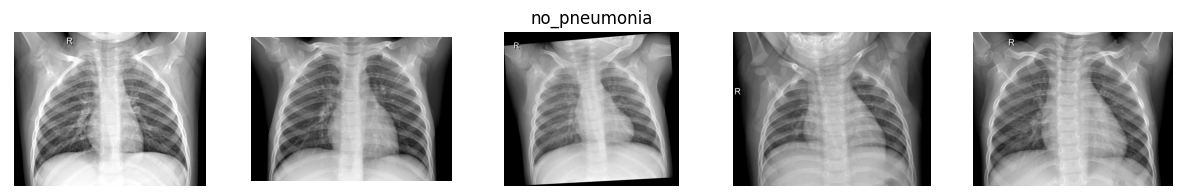

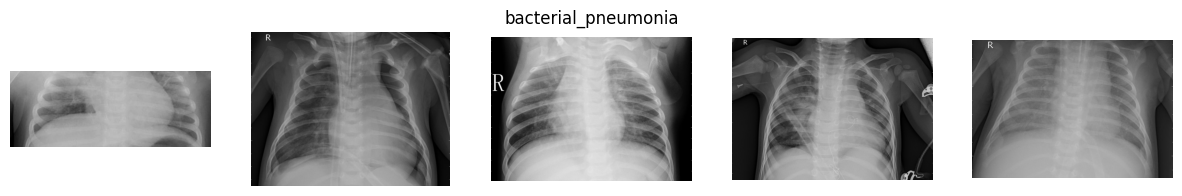

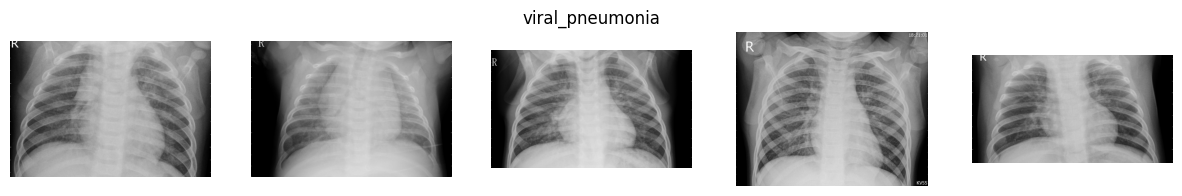

In [13]:
import os
import matplotlib.pyplot as plt

# Define the base directory
base_dir = 'final_train'

# Class folder names
classes = ['no_pneumonia', 'bacterial_pneumonia', 'viral_pneumonia']

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)
    
    plt.figure(figsize=(15, 2))
    plt.title(class_name)
    plt.axis('off')

    # Display 5 sample images from each class
    for i in range(5):
        img_path = os.path.join(folder_path, os.listdir(folder_path)[i])
        img = plt.imread(img_path)
        
        plt.subplot(1, 5, i + 1)
        plt.axis('off')
        plt.imshow(img, cmap="gray")
    
    plt.show()


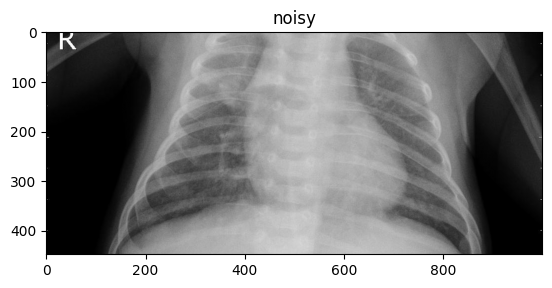

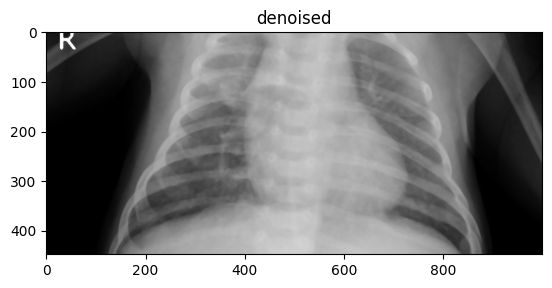

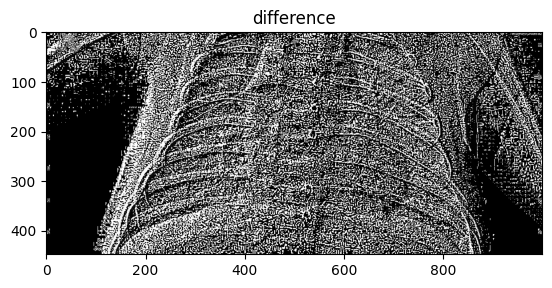

In [14]:
noisy_img = Image.open("final_train/viral_pneumonia/viral_pneumonia_100.jpg")
plt.title("noisy")
plt.imshow(noisy_img, cmap="gray")
plt.show()

filtered_img = scipy.ndimage.median_filter(noisy_img, size=6)
plt.title("denoised")
plt.imshow(filtered_img, cmap="gray")
plt.show()

diff_img = np.abs(filtered_img - noisy_img)
plt.title("difference")
plt.imshow(diff_img, cmap="gray")
plt.show()


## Preliminary plan for preprocessing
What needs fixing before modeling?

I believe the only thing left that needs fixing is the image size. Since images vary in size they will all needed to be transformed to the same size. We most likely will go with the proven 224x224 image size used in the skin lesion classification activity.

In [15]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from collections import Counter


# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.Grayscale(num_output_channels=3),  # Convert 1-channel -> 3-channel
    transforms.ToTensor(),
])

# Load the full dataset from a single clean folder
train_dataset = ImageFolder(root='final_train', transform=transform)

# Split into training and validation sets (e.g., 80% train, 20% val)
train_size = int(0.8 * len(train_dataset))
val_size = int(0.1 * len(train_dataset))
test_size = len(train_dataset) - train_size - val_size  # Ensures total matches

train_dataset, val_dataset, test_dataset = random_split(
    train_dataset, [train_size, val_size, test_size]
)
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)


def count_classes(subset, name):
    labels = [subset.dataset.samples[i][1] for i in subset.indices]
    counts = Counter(labels)
    print(f"\n{name} class distribution:")
    for class_idx in range(len(subset.dataset.classes)):
        print(f"Class {class_idx}: {counts[class_idx]}")

# Count in each dataset
count_classes(train_dataset, "Train")
count_classes(val_dataset, "Validation")
count_classes(test_dataset, "Test")

#################################### UN-COMMENT FOLLOWING CODE IF PULLING MODEL FROM WEB ####################################
'''
from torch import nn

num_classes = len(classes)
net = torchvision.models.resnet18(pretrained = True)

# We replace last layer of resnet to match our number of classes which is 7
net.fc = nn.Linear(512, num_classes)
net = net.to(device)
'''



Train class distribution:
Class 0: 1777
Class 1: 990
Class 2: 970

Validation class distribution:
Class 0: 224
Class 1: 129
Class 2: 114

Test class distribution:
Class 0: 237
Class 1: 108
Class 2: 123


'\nfrom torch import nn\n\nnum_classes = len(classes)\nnet = torchvision.models.resnet18(pretrained = True)\n\n# We replace last layer of resnet to match our number of classes which is 7\nnet.fc = nn.Linear(512, num_classes)\nnet = net.to(device)\n'

# DenseNet121

In [16]:
from torch import nn
import torchvision


net = torchvision.models.densenet121(pretrained = True) #loading pretrained densenet121 

# Replace last layer of resnet to match our number of classes
num_ftrs = net.classifier.in_features
net.classifier = nn.Linear(num_ftrs, 3)  # 3 classes
net = net.to(device) #copying the net to this device (which is cuda/gpu and if that isn't an option cpu)

/home/public/ekittell/COMP5300_venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/public/ekittell/COMP5300_venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/grad/masters/2025/ekittell/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100.0%


In [17]:
import torch.optim as optim

# Assuming class_weights is a dict like: {0: 1.0, 1: 2.5, ..., n: w}
# Convert it to a list or tensor in the correct order
weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight = class_weights_tensor) #using cross entropy loss with class weights for data class imbalance
optimizer = optim.Adam(net.parameters(), lr=1e-5) #Adam optimizer is being used with learning rate of 1e-5
print(net) #printing the network with these additions

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [19]:
from sklearn.metrics import accuracy_score

#helper functions for computing accuracy
def get_accuracy(predicted, labels):
    #tensor of predicted labels and tensor of true labels
    batch_len, correct= 0, 0
    #determines the batch size
    batch_len = labels.size(0)
    #comparing the predicted with the true labels to get the number of correct predictions
    correct = (predicted == labels).sum().item()
    #returning the batch size and the number of correct predictions
    return batch_len, correct

#function for evaluating the model on validation dataset
def evaluate(model, val_loader):
    #trained neural network and the validation data loader
    losses= 0
    num_samples_total=0
    #set up variables for evaluation
    correct_total=0
    #set model to evaluation mode
    model.eval()
    #iterating through validation dataset
    for inputs, labels in val_loader:
        #move input data and labels to device (cuda/GPU or CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)
        #determine predicted class
        _, predicted = torch.max(out, 1)
        #calculate loss
        loss = criterion(out, labels)
        losses += loss.item() 
        #count correct predictions
        b_len, corr = get_accuracy(predicted, labels)
        num_samples_total +=b_len
        #add up total correct
        correct_total +=corr
    #calculate accuracy
    accuracy = correct_total/num_samples_total
    #calculate loss
    losses = losses/len(val_loader)
    #return both
    return losses, accuracy

In [20]:
# number of loops over the dataset
num_epochs = 25
#set up arrays for accuracy
accuracy = []
val_accuracy = []
#set up arrays for losses
losses = []
val_losses = []

#training loop for the number of epocs specified
for epoch in range(num_epochs):
    #variable for monitoring training loss
    running_loss = 0.0
    #monitors for accuracy
    correct_total= 0.0
    num_samples_total=0.0
    #loop for iterating through training dataset
    for i, data in enumerate(train_loader):
        # get the inputs
        inputs, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        # set the parameter gradients to zero
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        #calculate loss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        #compute accuracy
        _, predicted = torch.max(outputs, 1)
        #using get_accuracy function to count the correct predictions
        b_len, corr = get_accuracy(predicted, labels)
        num_samples_total +=b_len
        #calculating the total correct predictions
        correct_total +=corr
        #calculating the total training loss
        running_loss += loss.item()

    #getting running loss and training accuracy
    running_loss /= len(train_loader)
    train_accuracy = correct_total/num_samples_total
    val_loss, val_acc = evaluate(net, val_loader)
    
    #print epochs
    print('Epoch: %d' %(epoch+1))
    #print training loss and accuracy
    print('Loss: %.3f  Accuracy:%.3f' %(running_loss, train_accuracy))
    #print validating loss and accuracy
    print('Validation Loss: %.3f  Val Accuracy: %.3f' %(val_loss, val_acc))

    #add all these loss/accuracy measurments to their respective arrays for later use
    losses.append(running_loss)
    val_losses.append(val_loss)
    accuracy.append(train_accuracy)
    val_accuracy.append(val_acc)
#print message to signify end of training loop
print('Finished Training')

Epoch: 1
Loss: 0.794  Accuracy:0.688
Validation Loss: 0.625  Val Accuracy: 0.792
Epoch: 2
Loss: 0.552  Accuracy:0.785
Validation Loss: 0.494  Val Accuracy: 0.818
Epoch: 3
Loss: 0.479  Accuracy:0.815
Validation Loss: 0.482  Val Accuracy: 0.797
Epoch: 4
Loss: 0.436  Accuracy:0.829
Validation Loss: 0.477  Val Accuracy: 0.801
Epoch: 5
Loss: 0.424  Accuracy:0.831
Validation Loss: 0.461  Val Accuracy: 0.820
Epoch: 6
Loss: 0.403  Accuracy:0.842
Validation Loss: 0.450  Val Accuracy: 0.799
Epoch: 7
Loss: 0.378  Accuracy:0.853
Validation Loss: 0.448  Val Accuracy: 0.827
Epoch: 8
Loss: 0.368  Accuracy:0.858
Validation Loss: 0.449  Val Accuracy: 0.824
Epoch: 9
Loss: 0.347  Accuracy:0.864
Validation Loss: 0.496  Val Accuracy: 0.809
Epoch: 10
Loss: 0.339  Accuracy:0.869
Validation Loss: 0.429  Val Accuracy: 0.820
Epoch: 11
Loss: 0.300  Accuracy:0.889
Validation Loss: 0.476  Val Accuracy: 0.829
Epoch: 12
Loss: 0.292  Accuracy:0.892
Validation Loss: 0.453  Val Accuracy: 0.833
Epoch: 13
Loss: 0.259  Ac

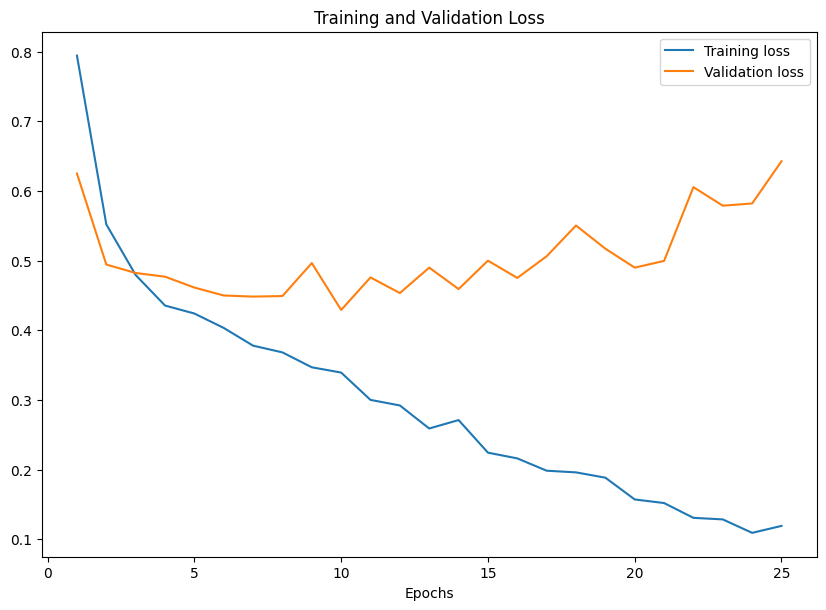

<Figure size 640x480 with 0 Axes>

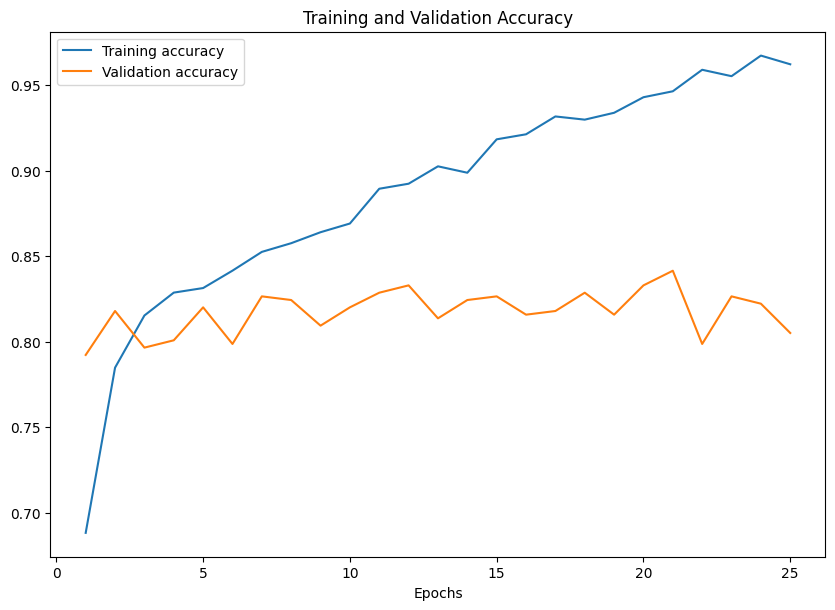

<Figure size 640x480 with 0 Axes>

In [21]:
# plt.plot(losses)
# plt.show()

#get epoch range for x axis of graph
epoch = range(1, num_epochs+1)
#set up a figure size 10x15 for our data
fig = plt.figure(figsize=(10, 15))
plt.subplot(2,1,2)
#plot measurements of training loss and validation loss
plt.plot(epoch, losses, label='Training loss')
plt.plot(epoch, val_losses, label='Validation loss')
#title for figure
plt.title('Training and Validation Loss')
#set epochs as x axis label
plt.xlabel('Epochs')
#create legend for different measurements
plt.legend()
plt.figure()
#show plot below notebook cell
plt.show()

#set up another figure
fig = plt.figure(figsize=(10, 15))
plt.subplot(2,1,2)
#plot both training accuracy and validation accuracy
plt.plot(epoch, accuracy, label='Training accuracy')
plt.plot(epoch, val_accuracy, label='Validation accuracy')
#set title
plt.title('Training and Validation Accuracy')
#set x axis title
plt.xlabel('Epochs')
#make legend for measurements
plt.legend()
plt.figure()
#show plot below cell
plt.show()

In [22]:
#variables for counting correct predictions
correct = 0
#total predictions
total = 0
net.eval()
with torch.no_grad():
    #loop for data in the test dataset
    for data in val_loader:
        images, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
         #compute accuracy
        _, predicted = torch.max(outputs.data, 1)
        #get total number of labels
        total += labels.size(0)
        #add up correct predictions
        correct += (predicted == labels).sum().item()

#print accuracy
print('Accuracy of the network on the test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the test images: 80 %


In [23]:
#make two lists for tracking accuracy of each class
class_correct = list(0. for i in range(len(classes)))
class_total = list(1e-7 for i in range(len(classes)))
with torch.no_grad():
    #loop for data in the test data loader
    for data in val_loader:
        images, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        #compute accuracy
        _, predicted = torch.max(outputs, 1)
        #using compare predicted with true label
        c = (predicted == labels).squeeze()
        #loop for adding to class correct and class total
        for i in range(3):
            label = labels[i]
            #adding to the correct predictions and total predictions for each class
            class_correct[label] += c[i].item()
            class_total[label] += 1

#printing the accuracy of each class
for i in range(len(classes)):
    print('Accuracy of %5s : %2d %%' % (
        #printing class and % out of 100
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of no_pneumonia : 69 %
Accuracy of bacterial_pneumonia : 99 %
Accuracy of viral_pneumonia : 87 %


In [24]:
#create confusion matric with size x and y of classes
confusion_matrix = torch.zeros(len(classes), len(classes))
with torch.no_grad():
    #loop for data in the test data loader
    for data in val_loader:
        images, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        #get predicted for accuracy
        _, predicted = torch.max(outputs, 1)
        #updates confusion matrix based on if a predicted label is the same as the true label
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1

#output confusion matrix as data below code cell
print(confusion_matrix)
cm = confusion_matrix.numpy()

tensor([[168.,   1.,  55.],
        [  4., 120.,   5.],
        [ 22.,   4.,  88.]])


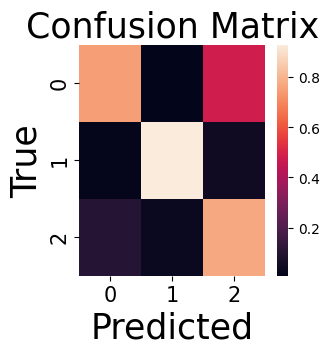

In [25]:
#set up figure to visually display data
fig,ax= plt.subplots(figsize=(3,3))
#create seaborn heatmap for visualizing confusion matrix
sns.heatmap(cm / (cm.astype(np.float64).sum(axis=1) + 1e-9), annot=False, ax=ax) #changed to float64

# labels, title and ticks
ax.set_xlabel('Predicted', size=25);
#setting x and y labels
ax.set_ylabel('True', size=25); 
#set title
ax.set_title('Confusion Matrix', size=25); 
#setting all labels for all classes in x and y axis
ax.xaxis.set_ticklabels(['0', '1', '2'], size=15); 
ax.yaxis.set_ticklabels(['0', '1', '2'], size=15);

plt.show() #added this